# Exploratory Data Analysis (EDA)

Before we build models or draw conclusions, we need to *understand* our data. That process is called **Exploratory Data Analysis (EDA)**.

Think of EDA like a doctor doing a check-up before prescribing treatment — you wouldn't skip straight to the diagnosis without first taking the patient's vitals, asking questions, and running some tests. EDA is that check-up for your dataset.

### What we'll do in this notebook

We'll work through a realistic dataset step by step, asking questions like:
- What does my data actually look like?
- Are there any gaps or errors?
- How are individual columns distributed?
- Do any values look suspiciously extreme?
- Are there patterns between different columns?
- Does anything change over time?

### The dataset

We'll use a synthetic **supermarket sales dataset** — 300 orders from 2023 across four product categories. It has been designed to contain realistic patterns, missing values, and outliers, so we have something interesting to discover.

| Column | Description |
|--------|-------------|
| `order_date` | Date the order was placed |
| `category` | Product category (Electronics, Clothing, Groceries, Sports) |
| `region` | Region of the store (North, South, East, West) |
| `quantity` | Number of items ordered |
| `unit_price` | Price of a single item ($) |
| `revenue` | Total sale value = quantity × unit_price ($) |
| `customer_age` | Age of the customer |
| `satisfaction` | Customer satisfaction rating (1–5) |

## 0. Setup

We only need four libraries for this tutorial:

| Library | What it's for |
|---------|---------------|
| `numpy` | Numerical operations (arrays, random numbers) |
| `pandas` | DataFrames — loading, filtering, grouping data |
| `matplotlib` | The foundation of Python plotting |
| `seaborn` | Higher-level charts built on top of matplotlib |

> 📚 **`numpy` was covered in [1.4 — Data Foundation with NumPy](../../1-data-fundamentals/1.4-data-foundation-linear-algebra/intro-numpy.md):** arrays, `np.random`, array statistics, and broadcasting.
>
> 📚 **`pandas` was covered in [1.5 — Data Analysis with Pandas](../../1-data-fundamentals/1.5-data-analysis-pandas/README.md):** Series, DataFrames, indexing, sorting, groupby, and more.
>
> 📚 **`matplotlib` and `seaborn` were introduced in [1.3 — Intro to Statistics](../../1-data-fundamentals/1.3-intro-statistics/one-variable-statistics.md):** `histplot`, `boxplot`, and basic chart customisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')   # clean background for all charts
np.random.seed(42)                 # makes random numbers reproducible

print('Ready!')

Ready!


## 1. Load & Inspect the Data

The very first thing to do with any new dataset is to **look at it**. Before writing a single line of analysis, you want to know:

- How many rows and columns are there?
- What type of data is in each column (numbers, text, dates)?
- Does the data look the way you expected?

We generate the dataset below so you don't need to download anything. In a real project, this cell would be replaced with `pd.read_csv('your_file.csv')`.

> 📚 **`pd.DataFrame` and `np.random` were covered in [1.4](../../1-data-fundamentals/1.4-data-foundation-linear-algebra/intro-numpy.md) and [1.5](../../1-data-fundamentals/1.5-data-analysis-pandas/dataframe.md):** constructing DataFrames from dictionaries, and generating random arrays with NumPy.

In [2]:
n = 300   # number of orders

# ── Categorical columns ────────────────────────────────────────────────────────
# p= sets the probability of each category being chosen
categories = np.random.choice(
    ['Electronics', 'Clothing', 'Groceries', 'Sports'], n,
    p=[0.25, 0.30, 0.30, 0.15]
)
regions = np.random.choice(['North', 'South', 'East', 'West'], n)

# ── Numeric columns ───────────────────────────────────────────────────────────
quantity = np.random.randint(1, 6, n)   # 1 to 5 items per order

# Each category has a different typical price
base_price = {'Electronics': 200, 'Clothing': 50, 'Groceries': 30, 'Sports': 80}
unit_price = np.array([base_price[c] for c in categories], dtype=float)
unit_price *= np.random.uniform(0.8, 1.2, n)   # ±20% price variation

revenue = (unit_price * quantity).round(2)

# ── Inject outliers ───────────────────────────────────────────────────────────
# 8 orders have unusually high revenue (e.g. bulk corporate orders)
revenue[np.random.choice(n, 8, replace=False)] *= 6

# ── Customer data ─────────────────────────────────────────────────────────────
age = np.random.normal(38, 10, n).clip(18, 70).astype(int)   # ages 18–70
satisfaction = np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.20, 0.40, 0.25])

# ── Dates ─────────────────────────────────────────────────────────────────────
dates = pd.date_range('2023-01-01', '2023-12-31', freq='D')
order_date = np.random.choice(dates, n)

# ── Assemble DataFrame ────────────────────────────────────────────────────────
df = pd.DataFrame({
    'order_date':   order_date,
    'category':     categories,
    'region':       regions,
    'quantity':     quantity,
    'unit_price':   unit_price.round(2),
    'revenue':      revenue,
    'customer_age': age,
    'satisfaction': satisfaction,
})

# ── Add missing values ────────────────────────────────────────────────────────
# ~5% of customer_age and satisfaction are missing (realistic!)
for col in ['customer_age', 'satisfaction']:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

df = df.sort_values('order_date').reset_index(drop=True)

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset shape: 300 rows × 8 columns


,order_date,category,region,quantity,unit_price,revenue,customer_age,satisfaction
0,2023-01-02,Clothing,East,1,48.10,48.10,26.0,2.0
1,2023-01-03,Clothing,North,5,44.10,220.51,20.0,3.0
2,2023-01-03,Groceries,West,5,33.34,166.71,43.0,3.0
3,2023-01-03,Groceries,West,1,25.67,154.02,42.0,3.0
4,2023-01-04,Electronics,South,4,239.82,959.26,36.0,3.0
5,2023-01-05,Sports,North,4,66.15,264.60,41.0,4.0
6,2023-01-07,Electronics,West,4,235.55,942.21,26.0,5.0
7,2023-01-10,Electronics,North,2,168.54,337.07,36.0,4.0
8,2023-01-12,Groceries,South,3,33.94,101.81,42.0,2.0
9,2023-01-13,Electronics,North,5,176.40,882.00,36.0,3.0


### 1a. Column types — `.info()`

`.info()` gives you a quick overview of every column:
- **Dtype** tells you whether a column holds integers, decimals, text, or dates
- **Non-Null Count** tells you how many rows have a real value (i.e. are not missing)

👉 Notice that `customer_age` and `satisfaction` show fewer than 300 non-null values — this is the missing data we introduced.

> 📚 **Covered in [1.5 — DataFrame](../../1-data-fundamentals/1.5-data-analysis-pandas/dataframe.md):** `.head()`, `.info()`, and the core DataFrame operations.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_date    300 non-null    datetime64[ns]
 1   category      300 non-null    object        
 2   region        300 non-null    object        
 3   quantity      300 non-null    int64         
 4   unit_price    300 non-null    float64       
 5   revenue       300 non-null    float64       
 6   customer_age  285 non-null    float64       
 7   satisfaction  285 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 18.9+ KB


### 1b. Summary statistics — `.describe()`

`.describe()` automatically computes the core statistics for every numeric column.

| Row | Meaning |
|-----|---------|
| `count` | Number of non-missing values |
| `mean` | Average value |
| `std` | Standard deviation — how spread out the values are |
| `min` / `max` | Smallest and largest values — check for anything impossible |
| `25%` / `50%` / `75%` | The quartiles (Q1, median, Q3) |

**Skew signal:** If `mean` is much larger than `50%` (median), the data is right-skewed — a small number of very large values are pulling the average up. Look at the `revenue` row as an example.

> 📚 **`.describe()` was covered in [1.5 — DataFrame](../../1-data-fundamentals/1.5-data-analysis-pandas/dataframe.md).**
>
> 📚 **Mean, median, std, and quartiles were covered in [1.3 — One-Variable Statistics](../../1-data-fundamentals/1.3-intro-statistics/one-variable-statistics.md):** measures of central tendency and spread.

In [4]:
df.describe()

,order_date,quantity,unit_price,revenue,customer_age,satisfaction
count,300,300.000000,300.000000,300.000000,285.000000,285.000000
mean,2023-06-18 19:45:36,2.986667,88.662733,284.695167,38.305263,3.628070
min,2023-01-02 00:00:00,1.000000,24.930000,25.470000,18.000000,1.000000
25%,2023-03-21 12:00:00,2.000000,34.472500,98.265000,32.000000,3.000000
50%,2023-06-08 12:00:00,3.000000,54.745000,172.195000,38.000000,4.000000
75%,2023-09-08 18:00:00,4.000000,167.257500,356.570000,46.000000,4.000000
max,2023-12-31 00:00:00,5.000000,239.820000,1698.780000,69.000000,5.000000
std,NaN,1.446882,68.504489,295.091593,10.772036,1.082146


## 2. Missing Values

Real-world data almost always has gaps. Missing values are a problem because:
- Some functions will silently skip them (giving you a wrong denominator)
- Others will crash entirely
- They can bias your results if the missingness is not random

The first step is simply to **count** how many values are missing in each column — before deciding what to do about them.

**How `.isnull()` works:** It returns a DataFrame of `True`/`False` values — `True` wherever a value is missing. Calling `.sum()` on that counts the `True` values per column (since `True` = 1, `False` = 0).

> 📚 **`.isnull()` and missing value handling were covered in [1.5 — Reindexing & Dropping](../../1-data-fundamentals/1.5-data-analysis-pandas/reindexing-dropping.md):** detecting and working with `NaN` values in a DataFrame.

In [5]:
# Build a summary table: count and percentage of missing values per column
missing = pd.DataFrame({
    'count':      df.isnull().sum(),
    'percentage': (df.isnull().sum() / len(df) * 100).round(1)
})

# Only show columns that actually have missing values
print('Columns with missing values:')
print(missing[missing['count'] > 0])

Columns with missing values:
              count  percentage
customer_age     15         5.0
satisfaction     15         5.0


A horizontal bar chart makes it easy to compare missing rates at a glance, especially when you have many columns.

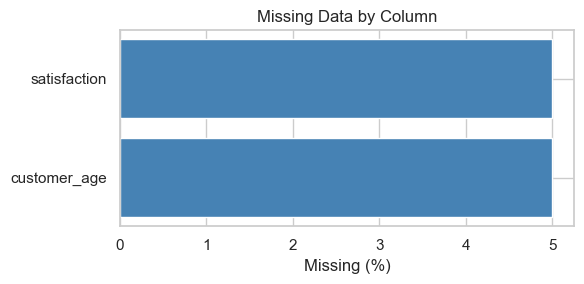

In [6]:
missing_cols = missing[missing['count'] > 0]

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(missing_cols.index, missing_cols['percentage'], color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Column')
plt.tight_layout()
plt.show()

> **What to do with missing values?** That depends on *why* they're missing and how many there are. With only ~5% missing here, common options are: drop those rows, fill with the column median, or leave them and let pandas handle it (most aggregation functions skip `NaN` by default). We'll leave them for now and revisit in the Data Wrangling module.

## 3. Univariate Analysis — One Column at a Time

"Univariate" means looking at a **single variable** in isolation. The goal is to understand its *distribution* — where do most values sit, how spread out are they, and is the shape symmetric or skewed?

We use two complementary charts side by side:

| Chart | What it shows |
|-------|---------------|
| **Histogram** | The shape of the distribution. The smooth curve (KDE) is a smoothed version of the histogram. The red dashed line is the **mean**, green is the **median**. |
| **Box plot** | Five-number summary in one picture: min, Q1, median, Q3, max. Dots outside the whiskers are flagged as potential outliers. |

**Tip — mean vs median:**
- If they line up → the distribution is roughly symmetric
- If the mean is much higher than the median → right-skewed (a few very large values pulling it up)
- If the mean is much lower than the median → left-skewed (a few very small values pulling it down)

> 📚 **Histograms and box plots were covered in [1.3 — One-Variable Statistics](../../1-data-fundamentals/1.3-intro-statistics/one-variable-statistics.md):** `sns.histplot`, `sns.boxplot`, and interpreting distribution shape.
>
> 📚 **Mean, median, and skewness were covered in [1.3 — One-Variable Statistics](../../1-data-fundamentals/1.3-intro-statistics/one-variable-statistics.md):** measures of central tendency and what skew tells you.

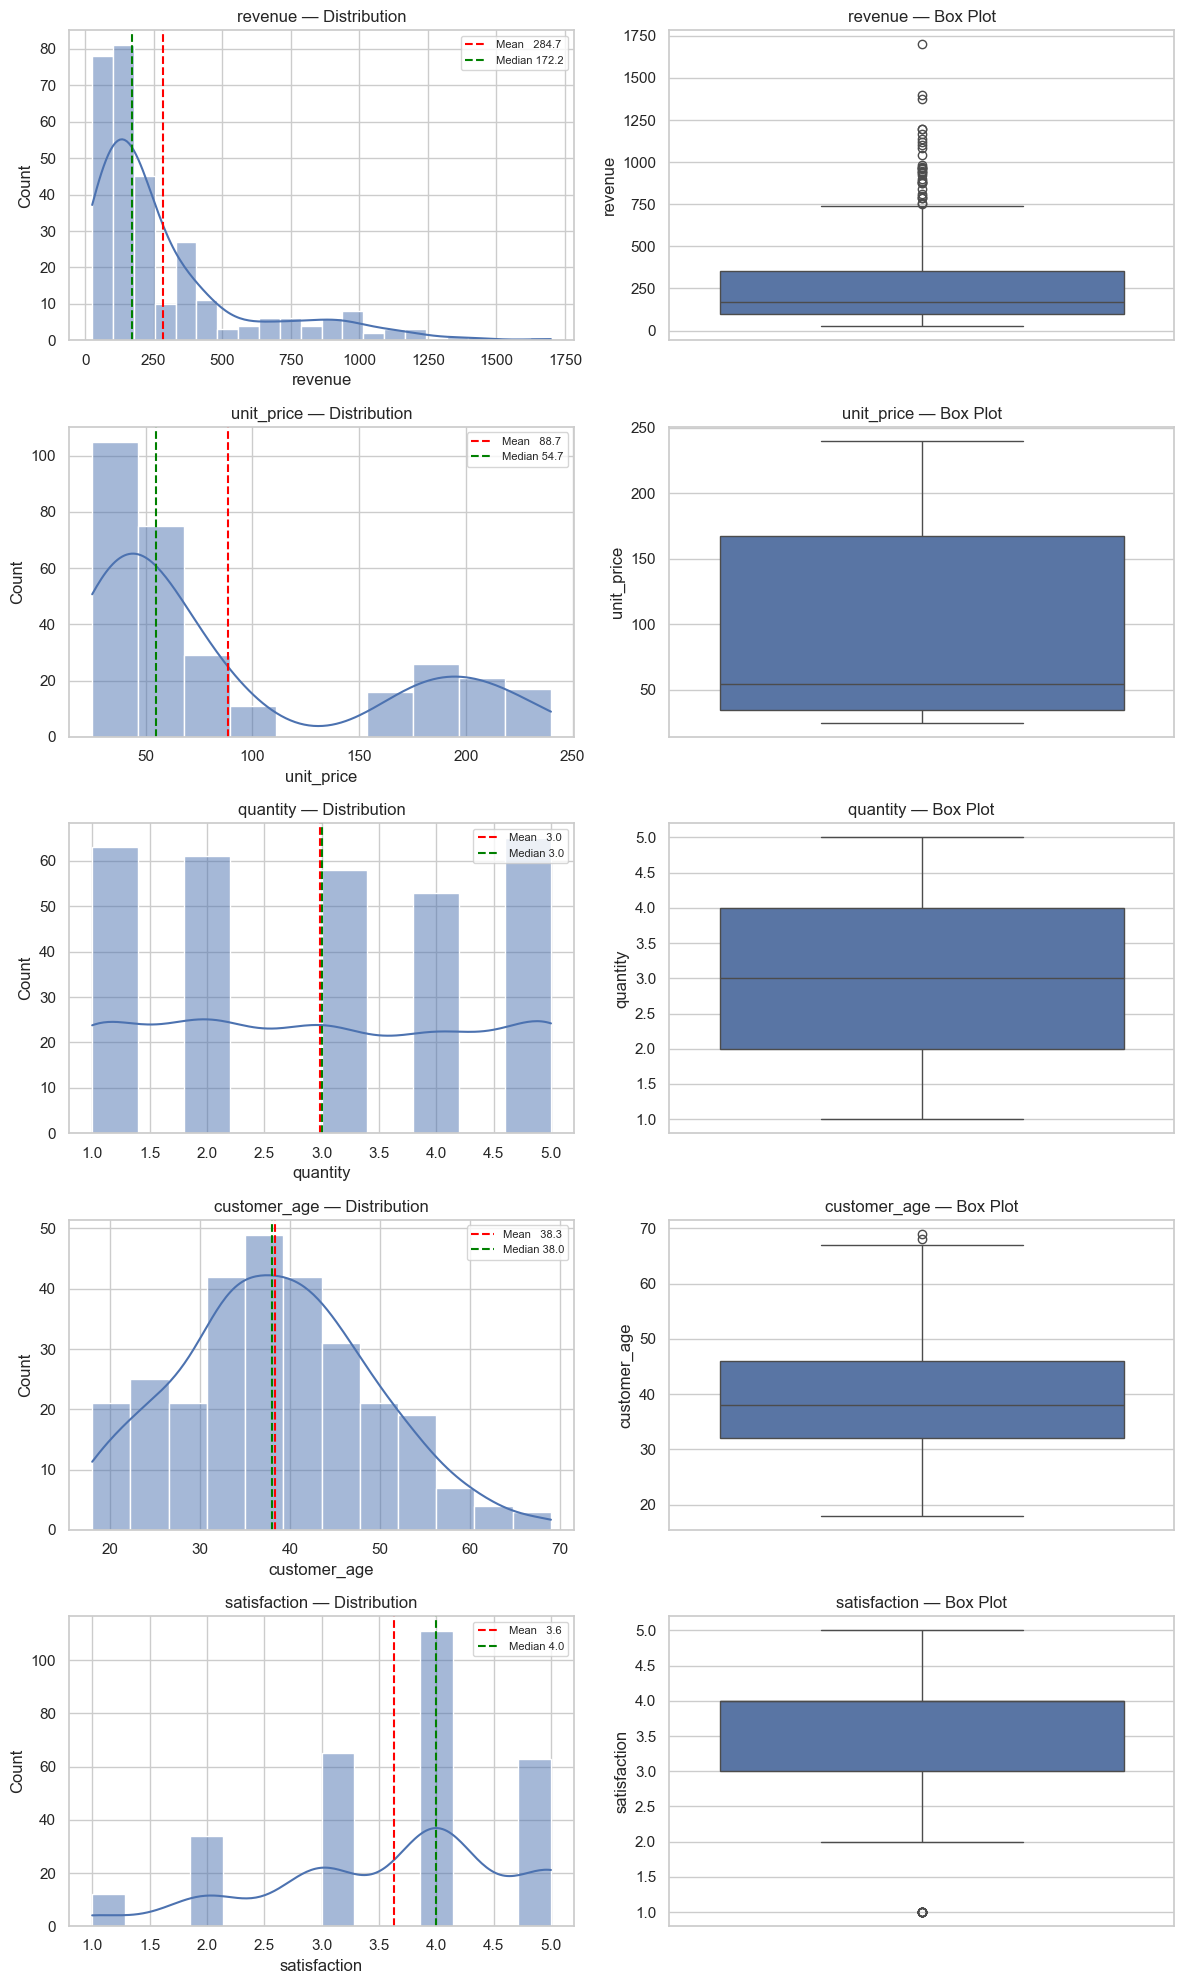

In [7]:
numeric_cols = ['revenue', 'unit_price', 'quantity', 'customer_age', 'satisfaction']

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()   # exclude missing values for plotting

    # Left: histogram with KDE and reference lines
    sns.histplot(data, kde=True, ax=axes[i, 0])
    axes[i, 0].axvline(data.mean(),   color='red',   linestyle='--',
                       label=f'Mean   {data.mean():.1f}')
    axes[i, 0].axvline(data.median(), color='green', linestyle='--',
                       label=f'Median {data.median():.1f}')
    axes[i, 0].set_title(f'{col} — Distribution')
    axes[i, 0].legend(fontsize=8)

    # Right: box plot
    sns.boxplot(y=data, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} — Box Plot')

plt.tight_layout()
plt.show()

### What did we find?

| Column | Shape | Mean vs Median | Takeaway |
|--------|-------|----------------|----------|
| `revenue` | Strong right skew | Mean >> Median | A few very large orders are inflating the average. Use median for "typical" revenue. |
| `unit_price` | Bimodal (two humps) | Similar | Reflects two price bands: cheap items (Groceries/Clothing) vs expensive (Electronics). |
| `quantity` | Roughly uniform | Similar | Customers order 1–5 items with roughly equal frequency. |
| `customer_age` | Roughly bell-shaped | Close | Ages cluster around mid-30s, as designed. |
| `satisfaction` | Left skew | Mean < Median | Most customers rate 4 or 5 — overall satisfaction is high. |

## 4. Categorical Analysis

For text columns (categories), a histogram doesn't make sense. Instead, we count **how often each value appears** using `.value_counts()`.

This tells us:
- Whether any category dominates the data (which could bias analysis)
- Whether any category is so rare it might cause problems
- Whether the categories look as expected

> 📚 **`.value_counts()` was covered in [1.5 — Series](../../1-data-fundamentals/1.5-data-analysis-pandas/series.md):** counting unique values in a pandas Series.

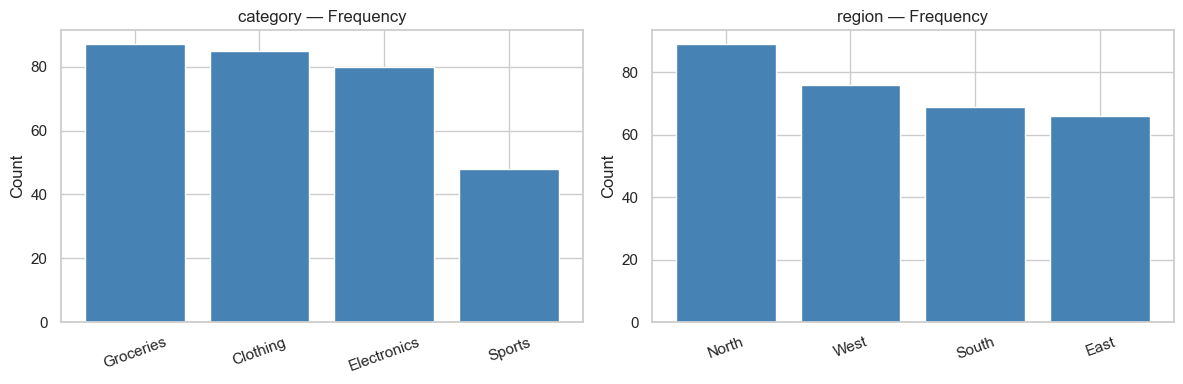

In [8]:
cat_cols = ['category', 'region']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(12, 4))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()   # sorted by frequency, largest first
    ax.bar(counts.index, counts.values, color='steelblue')
    ax.set_title(f'{col} — Frequency')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

Counts are useful, but **proportions** are easier to interpret when comparing across datasets of different sizes.

> 📚 **`normalize=True` in `.value_counts()` was covered in [1.5 — Series](../../1-data-fundamentals/1.5-data-analysis-pandas/series.md).**

In [9]:
# normalize=True converts counts to proportions (0–1), then ×100 for percentages
print('Category share of total orders:')
print((df['category'].value_counts(normalize=True) * 100).round(1).to_string())

Category share of total orders:
category
Groceries      29.0
Clothing       28.3
Electronics    26.7
Sports         16.0


> **Observation:** Groceries and Clothing together account for ~58% of orders, but we already know Electronics has much higher revenue per order. This kind of imbalance matters when interpreting totals.

## 5. Outlier Detection — The IQR Method

An **outlier** is a value that sits far away from the rest of the data. Outliers matter because:
- They can massively distort the mean and standard deviation
- They might represent **data errors** (typos, sensor glitches) — and should be removed
- Or they might be **real, important events** (a bulk order, a VIP customer) — and should be kept but handled carefully

### The IQR rule

The **interquartile range** is the distance between Q1 (25th percentile) and Q3 (75th percentile):

```
IQR = Q3 - Q1

Lower fence = Q1 - 1.5 × IQR    ← anything below this is an outlier
Upper fence = Q3 + 1.5 × IQR    ← anything above this is an outlier
```

This rule is robust because it's based on the middle 50% of the data, so a few extreme values don't affect where the fences are drawn.

> 📚 **IQR, Q1, Q3, and outlier detection were covered in [1.3 — One-Variable Statistics](../../1-data-fundamentals/1.3-intro-statistics/one-variable-statistics.md):** measures of spread, the IQR formula, and the 1.5×IQR fence rule.
>
> 📚 **`.quantile()` was covered in [1.5 — Series](../../1-data-fundamentals/1.5-data-analysis-pandas/series.md).**

In [10]:
def find_outliers(series):
    """Flag outliers in a numeric Series using the IQR method.
    
    Returns:
        mask   - boolean Series, True where value is an outlier
        lower  - lower fence value
        upper  - upper fence value
    """
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper


mask, lower, upper = find_outliers(df['revenue'])

Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)

print(f'Q1 = {Q1:.0f},  Q3 = {Q3:.0f},  IQR = {Q3 - Q1:.0f}')
print(f'Lower fence: {lower:.0f}')
print(f'Upper fence: {upper:.0f}')
print(f'Outliers found: {mask.sum()} rows')
print()
print('Sample of outlier rows:')
print(df.loc[mask, ['order_date', 'category', 'quantity', 'revenue']].head(8))

Q1 = 98,  Q3 = 357,  IQR = 258
Lower fence: -289
Upper fence: 744
Outliers found: 32 rows

Sample of outlier rows:
   order_date     category  quantity  revenue
4  2023-01-04  Electronics         4   959.26
6  2023-01-07  Electronics         4   942.21
9  2023-01-13  Electronics         5   882.00
14 2023-01-19  Electronics         5   969.44
21 2023-01-22  Electronics         4   799.19
33 2023-02-07     Clothing         5  1399.68
39 2023-02-16  Electronics         5   874.53
41 2023-02-18       Sports         2   874.62


Now let's visualise the outliers. The box plot does this automatically (dots beyond the whiskers), but a scatter plot lets us see *where* they sit across the dataset.

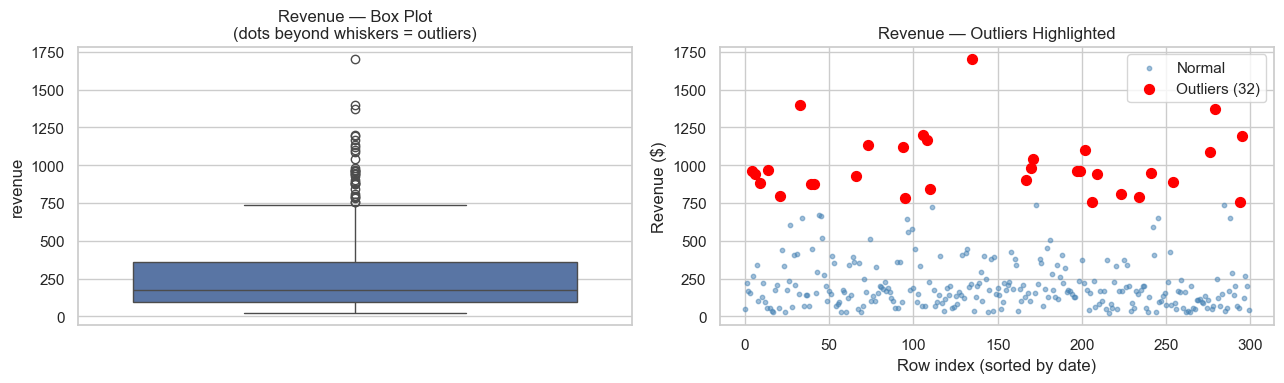

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot: dots beyond the whiskers are automatically flagged as outliers
sns.boxplot(y=df['revenue'], ax=axes[0])
axes[0].set_title('Revenue — Box Plot\n(dots beyond whiskers = outliers)')

# Scatter: paint outliers red so we can see where they sit
axes[1].scatter(df.index[~mask], df.loc[~mask, 'revenue'],
                s=10, alpha=0.5, color='steelblue', label='Normal')
axes[1].scatter(df.index[mask], df.loc[mask, 'revenue'],
                s=50, color='red', label=f'Outliers ({mask.sum()})')
axes[1].set_xlabel('Row index (sorted by date)')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_title('Revenue — Outliers Highlighted')
axes[1].legend()

plt.tight_layout()
plt.show()

> **Interpretation:** The outliers are scattered throughout the year (not clustered in one period), which suggests they are individual bulk orders rather than a data entry error affecting a specific time range. In a real project we'd investigate a few manually before deciding whether to keep or remove them.

## 6. Bivariate Analysis — Two Variables at a Time

After studying each column individually, we look at **pairs of variables** to find relationships. This is called bivariate ("bi" = two) analysis.

There are three types of pairings:

| Pairing | Best tool |
|---------|-----------|
| Numeric vs Numeric | Scatter plot, correlation |
| Numeric vs Categorical | Box plot per group |
| Categorical vs Categorical | Contingency table / stacked bar |

### 6a. Numeric vs Numeric — Scatter Plots

A **scatter plot** puts one variable on each axis and draws a dot for every row. The resulting pattern (or lack of one) tells you whether the two variables move together.

- **Dots trending up-right** → positive relationship (both increase together)
- **Dots trending down-right** → negative relationship (one goes up as the other goes down)
- **No pattern / cloud of dots** → little or no relationship

> 📚 **Scatter plots and positive/negative relationships were introduced conceptually in [1.3 — Two-Variable Statistics](../../1-data-fundamentals/1.3-intro-statistics/two-variable-statistics.md).** Here we're producing them in code for the first time.

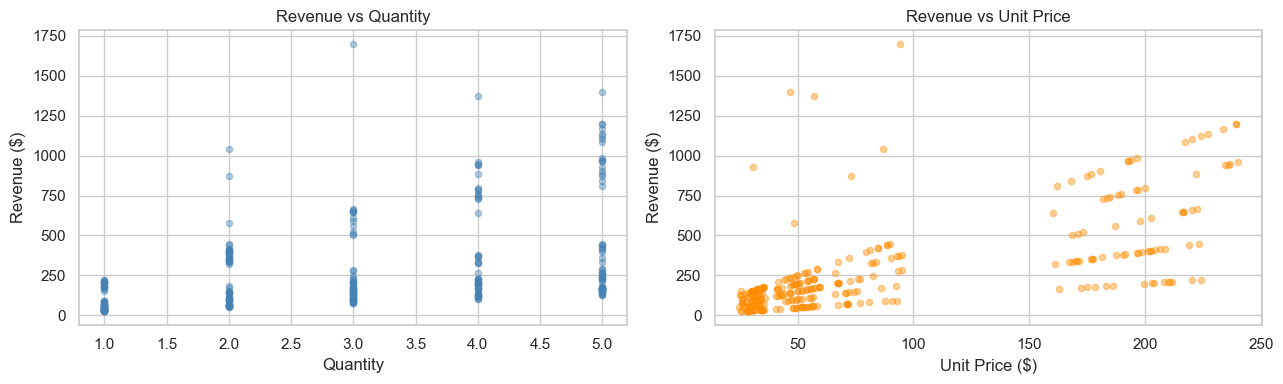

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Revenue vs Quantity
# Expectation: more items → more revenue
axes[0].scatter(df['quantity'], df['revenue'], alpha=0.4, s=20, color='steelblue')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_title('Revenue vs Quantity')

# Revenue vs Unit Price
# Expectation: more expensive item → higher revenue
axes[1].scatter(df['unit_price'], df['revenue'], alpha=0.4, s=20, color='darkorange')
axes[1].set_xlabel('Unit Price ($)')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_title('Revenue vs Unit Price')

plt.tight_layout()
plt.show()

> **Observation:** The `unit_price` vs `revenue` chart shows a clearer upward trend than `quantity` vs `revenue`. This makes intuitive sense — a $200 item dominates the total sale value more than an extra unit of a $30 item.

### 6b. Correlation — Putting a Number on Relationships

A scatter plot shows the *shape* of a relationship, but we also want a **number** that summarises its strength and direction. That number is the **correlation coefficient** (Pearson's *r*).

```
 r = +1.0  →  perfect positive relationship
 r =  0.0  →  no linear relationship
 r = -1.0  →  perfect negative relationship
```

A **correlation matrix** computes *r* for every pair of numeric columns at once. We display it as a heatmap:
- **Warm colours (red)** → positive correlation
- **Cool colours (blue)** → negative correlation
- **White / near zero** → no linear relationship
- The diagonal is always 1.0 (a variable is perfectly correlated with itself)

> 📚 **The concept of correlation (positive, negative, strength, and Pearson's *r*) was covered in [1.3 — Two-Variable Statistics](../../1-data-fundamentals/1.3-intro-statistics/two-variable-statistics.md).** The pandas method `.corr()` and the heatmap visualisation are new here.

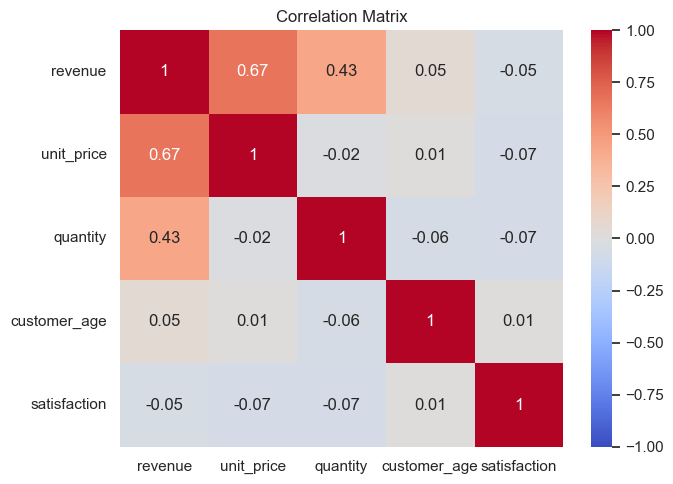

In [13]:
# .corr() computes Pearson's r between every pair of numeric columns
corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,      # show the r value inside each cell
    cmap='coolwarm', # red = positive, blue = negative
    center=0,        # white = zero correlation
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

> **What to read here:**
> - `unit_price` and `revenue` have the strongest correlation — higher-priced items drive revenue the most
> - `quantity` and `revenue` also correlate positively, but more weakly
> - `customer_age` and `satisfaction` have near-zero correlation with revenue — knowing someone's age or rating tells you little about how much they spent
>
> ⚠️ **Reminder from 1.3:** Correlation measures *linear* relationships only, and a high correlation does not mean one variable *causes* the other.

### 6c. Numeric vs Categorical — Box Plots per Group

When one variable is categorical (like `category`) and the other is numeric (like `revenue`), we compare the *distribution* of the numeric variable across each group.

A box plot per group is perfect for this — it lets you see at a glance whether different categories have different typical values and different amounts of spread.

We sort the categories by their **median** revenue so the chart reads naturally from lowest to highest.

> 📚 **Sorting by an aggregated value uses `.groupby()` with `.sort_values()`, covered in [1.5 — Sorting & Ranking](../../1-data-fundamentals/1.5-data-analysis-pandas/sorting-ranking.md).**

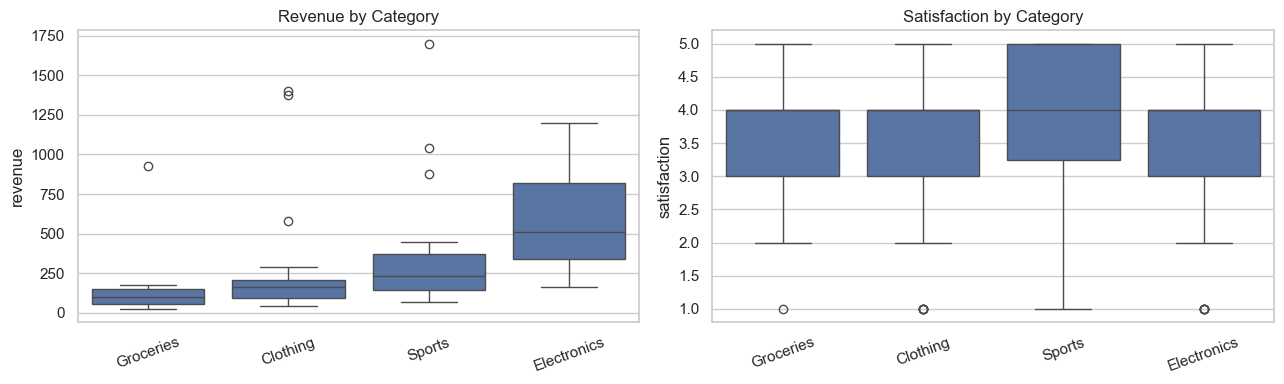

In [14]:
# Sort categories by median revenue (lowest to highest)
category_order = df.groupby('category')['revenue'].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Revenue by category
sns.boxplot(data=df, x='category', y='revenue', order=category_order, ax=axes[0])
axes[0].set_title('Revenue by Category')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Satisfaction by category — does expensive = happier?
sns.boxplot(data=df, x='category', y='satisfaction', order=category_order, ax=axes[1])
axes[1].set_title('Satisfaction by Category')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

> **Observations:**
> - Electronics has the highest median revenue *and* the widest box — prices vary a lot within that category
> - Satisfaction scores are similar across all categories — higher spend does not seem to mean happier customers in this data

## 7. Groupby Summaries

Scatter plots and box plots show individual data points, but often we want **aggregated totals**: what is the total revenue per category? What is the average satisfaction by region?

This is where `.groupby()` and `.pivot_table()` shine.

> 📚 **`.groupby()` and aggregation functions (`.sum()`, `.mean()`, `.agg()`) were covered in [1.5 — DataFrame](../../1-data-fundamentals/1.5-data-analysis-pandas/dataframe.md).**
>
> 📚 **`pivot_table()` was covered in [1.5 — Function Mapping](../../1-data-fundamentals/1.5-data-analysis-pandas/function-mapping.md):** reshaping data across two categorical dimensions.

In [15]:
# Aggregate revenue by category — compute several stats at once
rev_by_cat = (
    df.groupby('category')['revenue']
    .agg(total='sum', median='median', mean='mean', order_count='count')
    .round(1)
    .sort_values('total', ascending=False)
)

print('Revenue by category:')
print(rev_by_cat)

Revenue by category:
               total  median   mean  order_count
category                                        
Electronics  46201.8   508.7  577.5           80
Clothing     15540.9   161.0  182.8           85
Sports       14338.1   229.5  298.7           48
Groceries     9327.7    98.5  107.2           87


Notice that we display **both** total and median revenue:
- **Total** tells us where the money comes from overall
- **Median** tells us what a typical order looks like — it is not skewed by the outliers we found earlier

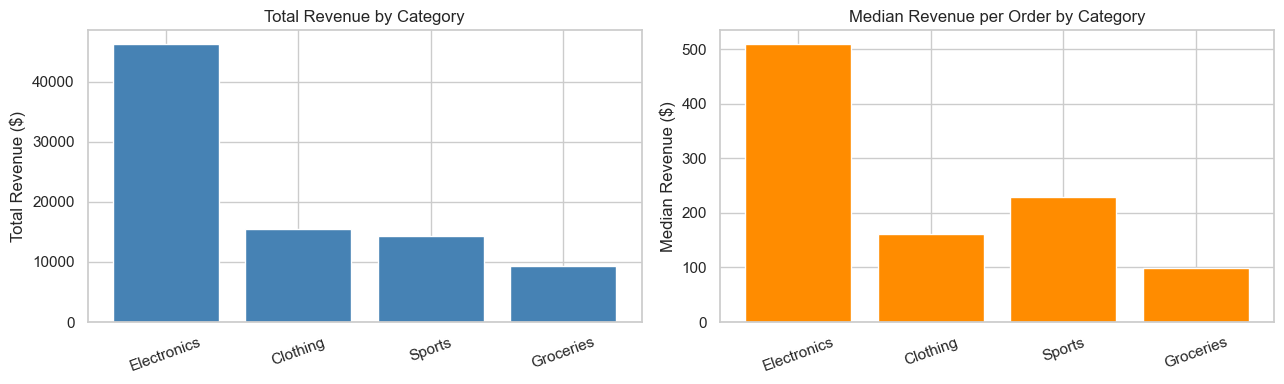

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(rev_by_cat.index, rev_by_cat['total'], color='steelblue')
axes[0].set_title('Total Revenue by Category')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(rev_by_cat.index, rev_by_cat['median'], color='darkorange')
axes[1].set_title('Median Revenue per Order by Category')
axes[1].set_ylabel('Median Revenue ($)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Pivot tables — two dimensions at once

A **pivot table** lets you break data down by *two* categorical variables simultaneously. Here we look at median revenue for every combination of `region` and `category`.

This answers the question: *"Does Electronics outperform other categories equally in all regions, or only in some?"*

In [17]:
pivot = df.pivot_table(
    values='revenue',
    index='region',
    columns='category',
    aggfunc='median'
).round(0)

print('Median revenue — region × category:')
print(pivot)

Median revenue — region × category:
category  Clothing  Electronics  Groceries  Sports
region                                            
East         177.0        650.0       98.0   185.0
North        127.0        446.0       93.0   327.0
South        150.0        410.0      102.0   201.0
West         163.0        455.0      102.0   336.0


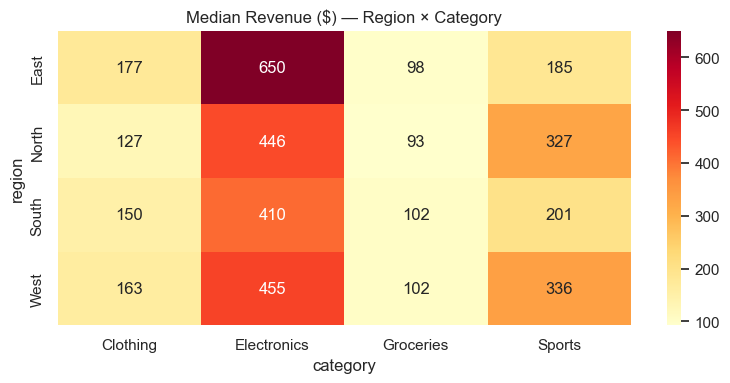

In [18]:
# A heatmap is the clearest way to read a pivot table
# Darker colour = higher median revenue
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Median Revenue ($) — Region × Category')
plt.tight_layout()
plt.show()

> **Observation:** Electronics dominates revenue in all four regions — the pattern is consistent, not just a regional quirk. Groceries has the lowest median revenue everywhere, which makes sense given its low unit prices.

## 8. Time Trends

When a dataset spans a period of time, it's worth asking: **does anything change over time?** For example:
- Are sales growing month over month?
- Is there a seasonal peak (e.g. around the holidays)?
- Did something unusual happen in one particular month?

Pandas makes time-based analysis easy with the `.dt` accessor, which lets you extract parts of a date (year, month, day of week, etc.) from a datetime column.

> 📚 **`.groupby()` was covered in [1.5 — DataFrame](../../1-data-fundamentals/1.5-data-analysis-pandas/dataframe.md).**
>
> 🆕 **The `.dt` accessor and `pd.date_range()` are new in this module.** Extracting date components (`.dt.month`, `.dt.dayofweek`) is a key skill for time-based EDA.

In [19]:
# Extract month number (1 = January, 12 = December)
df['month'] = df['order_date'].dt.month

# Aggregate by month
monthly = df.groupby('month')['revenue'].agg(total='sum', orders='count')

# Replace numeric month index with readable labels
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
monthly.index = month_labels

print(monthly)

        total  orders
Jan   9181.11      30
Feb   8473.14      21
Mar   8656.30      37
Apr  11388.25      31
May   5756.53      23
Jun   4657.57      22
Jul   9199.53      28
Aug   8054.26      27
Sep   4724.54      19
Oct   4042.24      15
Nov   3007.91      22
Dec   8267.17      25


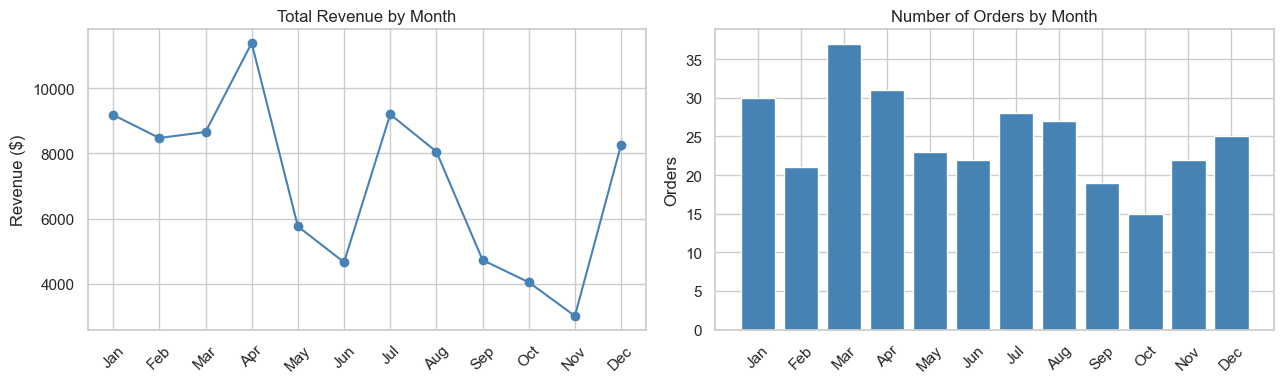

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Line chart: good for showing trends over time
axes[0].plot(monthly.index, monthly['total'], marker='o', color='steelblue')
axes[0].set_title('Total Revenue by Month')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart: good for comparing discrete counts
axes[1].bar(monthly.index, monthly['orders'], color='steelblue')
axes[1].set_title('Number of Orders by Month')
axes[1].set_ylabel('Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

A **stacked bar chart** lets us break down each month's total by category — so we can see not just whether revenue rises or falls, but *which category* is driving the change.

> 🆕 **`.unstack()`** pivots one level of a MultiIndex into columns — useful when you have grouped by two dimensions and want to plot them side by side. This is a new technique introduced here.

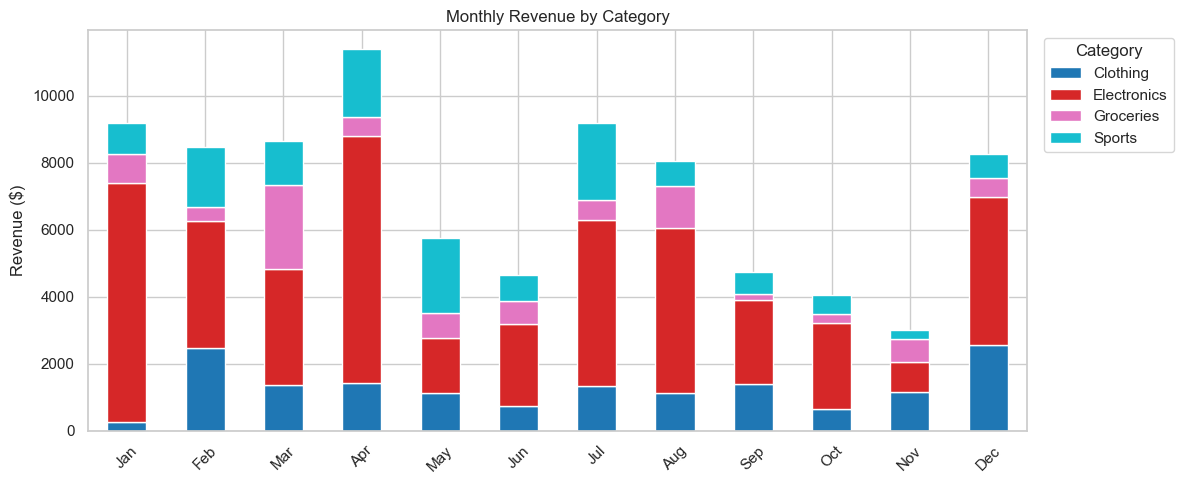

In [21]:
# Group by month AND category, then pivot categories into columns
monthly_cat = df.groupby(['month', 'category'])['revenue'].sum().unstack()
monthly_cat.index = month_labels

monthly_cat.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab10')
plt.title('Monthly Revenue by Category')
plt.ylabel('Revenue ($)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

> **Observation:** Electronics (typically the largest segment) drives most of the month-to-month variation in total revenue. In months where overall revenue dips, it's usually because fewer Electronics orders came through.

## 9. EDA Summary

A good EDA always ends with a plain-English summary of what you found. This is what you'd share with a manager or client before moving on to deeper analysis or modelling.

In [22]:
rev = df['revenue']
Q1, Q3 = rev.quantile(0.25), rev.quantile(0.75)
n_outliers = ((rev < Q1 - 1.5*(Q3-Q1)) | (rev > Q3 + 1.5*(Q3-Q1))).sum()
top_cat = df.groupby('category')['revenue'].sum().idxmax()
corr_with_rev = df[numeric_cols].corr()['revenue'].drop('revenue').abs().sort_values(ascending=False)

print('=' * 55)
print('EDA SUMMARY — Supermarket Sales 2023')
print('=' * 55)
print(f'\nDataset   : {df.shape[0]} orders across {df["month"].nunique()} months')
print(f'Columns   : {df.shape[1]} ({len(numeric_cols)} numeric, 2 categorical, 1 date)')
print(f'\nMissing values:')
for col, n in df.isnull().sum()[df.isnull().sum() > 0].items():
    print(f'  {col}: {n} rows ({n/len(df)*100:.0f}%)')
print(f'\nRevenue distribution (right-skewed):')
print(f'  Median  : ${rev.median():.0f}')
print(f'  Mean    : ${rev.mean():.0f}  (inflated by outliers)')
print(f'  Outliers: {n_outliers} rows flagged by IQR rule')
print(f'\nTop category by total revenue: {top_cat}')
print(f'\nStrongest correlation with revenue:')
print(f'  {corr_with_rev.index[0]}: r = {df[numeric_cols].corr()["revenue"][corr_with_rev.index[0]]:.2f}')
print(f'  {corr_with_rev.index[1]}: r = {df[numeric_cols].corr()["revenue"][corr_with_rev.index[1]]:.2f}')

EDA SUMMARY — Supermarket Sales 2023

Dataset   : 300 orders across 12 months
Columns   : 9 (5 numeric, 2 categorical, 1 date)

Missing values:
  customer_age: 15 rows (5%)
  satisfaction: 15 rows (5%)

Revenue distribution (right-skewed):
  Median  : $172
  Mean    : $285  (inflated by outliers)
  Outliers: 32 rows flagged by IQR rule

Top category by total revenue: Electronics

Strongest correlation with revenue:
  unit_price: r = 0.67
  quantity: r = 0.43


### EDA Workflow Recap

| # | Step | Key tool | Prior module | Question answered |
|---|------|----------|-------------|-------------------|
| 1 | Load & inspect | `.head()`, `.info()`, `.describe()` | 1.5 Pandas | What does the data look like? |
| 2 | Missing values | `.isnull().sum()` | 1.5 Pandas | Where are the gaps? |
| 3 | Univariate analysis | `histplot`, `boxplot`, mean/median | 1.3 Statistics | How is each column distributed? |
| 4 | Categorical analysis | `.value_counts()`, bar chart | 1.5 Pandas | How are categories represented? |
| 5 | Outlier detection | IQR fences, `.quantile()` | 1.3 Statistics | Which values are unusually extreme? |
| 6 | Bivariate analysis | Scatter plots, `.corr()`, grouped boxplot | 1.3 Statistics (concept) | How do variables relate to each other? |
| 7 | Groupby summaries | `.groupby()`, `.agg()`, `pivot_table` | 1.5 Pandas | What are the aggregated patterns by group? |
| 8 | Time trends | `.dt.month`, `.unstack()` | 🆕 New here | Does anything change over time? |

### What comes next?

EDA feeds directly into the next stages of the data science workflow:
- **Data Wrangling** — fixing the issues EDA revealed (missing values, outliers, wrong types)
- **Data Visualisation** — producing polished charts to communicate findings to others
- **Feature Engineering & Modelling** — using the relationships discovered here to build predictive models